# Unsupervised Learning Exploration on Real Transaction Data

This notebook implements a complete unsupervised learning workflow on a real-world credit card transaction dataset (~50,000 rows).

The pipeline includes:
- Data loading and preprocessing
- Dimensionality reduction with Truncated SVD
- Clustering with KMeans, DBSCAN, and Gaussian Mixture Model (GMM)
- Cluster quality comparison using standard metrics
- Anomaly detection with Isolation Forest
- Cluster and anomaly summaries

All code cells are heavily commented so that each step is easy to follow.


In [1]:
# Import required libraries

import numpy as np                    # Numerical computations and arrays
import pandas as pd                  # Working with tabular data (DataFrames)
import matplotlib.pyplot as plt      # Plotting library
import seaborn as sns                # Statistical plotting on top of matplotlib

from sklearn.compose import ColumnTransformer      # To apply different preprocessing to numeric/categorical columns
from sklearn.pipeline import Pipeline              # To build processing pipelines
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # Encoding and scaling
from sklearn.impute import SimpleImputer          # Filling in missing values

from sklearn.decomposition import TruncatedSVD    # Dimensionality reduction for sparse/high-dimensional data
from sklearn.cluster import KMeans, DBSCAN        # Clustering algorithms
from sklearn.mixture import GaussianMixture       # Gaussian Mixture Model (GMM) clustering
from sklearn.metrics import (                     # Clustering quality metrics
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.ensemble import IsolationForest      # Anomaly detection algorithm

import warnings                                   # To control warning messages
warnings.filterwarnings("ignore")                # Ignore warnings to keep the output clean

# Set default plotting parameters
plt.rcParams["figure.figsize"] = (6, 4)          # Default figure size
plt.rcParams["figure.dpi"] = 120                 # Default resolution


In [2]:
# Step 1: Load dataset


csv_path = "/content/50k(Sheet1).csv"      # Path to the CSV file (adjust if needed)
df = pd.read_csv(csv_path)        # Read the CSV into a pandas DataFrame

print("Original shape:", df.shape)  # Show number of rows and columns
df.head()                           # Display first 5 rows for a quick look


Original shape: (50566, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0.0,1/1/2019 0:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495.0,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0,28705.0
1,1.0,1/1/2019 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149.0,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0,NaN
2,2.0,1/1/2019 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154.0,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0,83236.0
3,3.0,1/1/2019 0:01,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939.0,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0,NaN
4,4.0,1/1/2019 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99.0,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0,22844.0


In [3]:
# Step 2: Data Cleaning & Preprocessing

# We treat 'merch_zipcode' slightly differently: allow NaN there for now
cols_except_merch_zip = [c for c in df.columns if c != "merch_zipcode"]  # All columns except merch_zipcode

# Drop rows where all non-merch_zipcode columns have missing values
df_clean = df.dropna(subset=cols_except_merch_zip).copy()

# Impute missing values in 'merch_zipcode' with its median
df_clean["merch_zipcode"] = df_clean["merch_zipcode"].fillna(
    df_clean["merch_zipcode"].median()
)

print("After basic NaN handling:", df_clean.shape)  # New shape after removing NaNs

# Convert transaction datetime column to pandas datetime type
df_clean["trans_date_trans_time"] = pd.to_datetime(df_clean["trans_date_trans_time"])

# Convert date of birth column to pandas datetime type
df_clean["dob"] = pd.to_datetime(df_clean["dob"])

# Extract hour of transaction from timestamp (0–23)
df_clean["trans_hour"] = df_clean["trans_date_trans_time"].dt.hour

# Extract day of week (0=Monday, 6=Sunday)
df_clean["trans_dayofweek"] = df_clean["trans_date_trans_time"].dt.dayofweek

# Extract month of transaction (1–12)
df_clean["trans_month"] = df_clean["trans_date_trans_time"].dt.month

# Compute customer's age in years at the time of transaction
df_clean["age"] = (df_clean["trans_date_trans_time"] - df_clean["dob"]).dt.days / 365.25

# Columns considered ID-like or unhelpful for clustering (too unique or textual)
drop_cols = [
    "Unnamed: 0",              # Index-like column
    "trans_date_trans_time",   # Raw timestamp (we already have derived features)
    "dob",                     # Raw date of birth (we use age instead)
    "trans_num",               # Transaction ID
    "cc_num",                  # Credit card number (ID)
    "street",                  # Street name (high-cardinality text)
    "first",                   # First name
    "last"                     # Last name
]

# Drop these columns from the cleaned DataFrame
df_clean = df_clean.drop(columns=drop_cols)

print("After dropping ID/text columns:", df_clean.shape)  # Show shape after dropping columns

# If the label 'is_fraud' exists, separate it from features
if "is_fraud" in df_clean.columns:
    y_label = df_clean["is_fraud"].copy()           # Save labels as y_label
    X = df_clean.drop(columns=["is_fraud"])         # All remaining columns are features
else:
    y_label = None                                  # No labels available
    X = df_clean.copy()                             # All columns are features

print("Feature matrix shape:", X.shape)             # Show final feature matrix size

# Identify numeric columns (int or float)
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identify categorical columns (object / string type)
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", num_cols)                 # List numeric feature names
print("Categorical columns:", cat_cols)             # List categorical feature names

# Define preprocessing for numeric data:
#   - Impute missing values with median
#   - Scale with StandardScaler
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # Fill missing numeric values with median
    ("scaler", StandardScaler())                     # Standardize features (mean=0, std=1)
])

# Define preprocessing for categorical data:
#   - Impute missing values with most frequent category
#   - One-hot encode categories
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),    # Fill missing categories with most frequent
    ("onehot", OneHotEncoder(handle_unknown="ignore"))       # One-hot encode categorical features
])

# Combine numeric and categorical transformers into a single ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),   # Apply numeric pipeline to numeric columns
        ("cat", categorical_transformer, cat_cols) # Apply categorical pipeline to categorical columns
    ]
)

# Fit the preprocessing pipelines and transform the feature matrix
X_processed = preprocess.fit_transform(X)
print("Processed feature matrix shape:", X_processed.shape)  # Shape after preprocessing


After basic NaN handling: (50563, 24)
After dropping ID/text columns: (50563, 20)
Feature matrix shape: (50563, 19)
Numeric columns: ['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'merch_zipcode', 'age']
Categorical columns: ['merchant', 'category', 'gender', 'city', 'state', 'job']
Processed feature matrix shape: (50563, 2083)


Cumulative explained variance by SVD components:

Component 1: 0.2373
Component 2: 0.3731
Component 3: 0.4423
Component 4: 0.5073
Component 5: 0.5721
Component 6: 0.6301
Component 7: 0.6344
Component 8: 0.6624
Component 9: 0.6839
Component 10: 0.6905
Component 11: 0.6968
Component 12: 0.7029
Component 13: 0.7086
Component 14: 0.7142
Component 15: 0.7195
Component 16: 0.7245
Component 17: 0.7292
Component 18: 0.7339
Component 19: 0.7384
Component 20: 0.7427
Component 21: 0.7468
Component 22: 0.7507
Component 23: 0.7542
Component 24: 0.7572
Component 25: 0.7597
Component 26: 0.7621
Component 27: 0.7645
Component 28: 0.7669
Component 29: 0.7691
Component 30: 0.7713
Component 31: 0.7734
Component 32: 0.7754
Component 33: 0.7773
Component 34: 0.7790
Component 35: 0.7807
Component 36: 0.7823
Component 37: 0.7840
Component 38: 0.7856
Component 39: 0.7871
Component 40: 0.7887
Component 41: 0.7902
Component 42: 0.7917
Component 43: 0.7932
Component 44: 0.7947
Component 45: 0.7961
Component 46: 

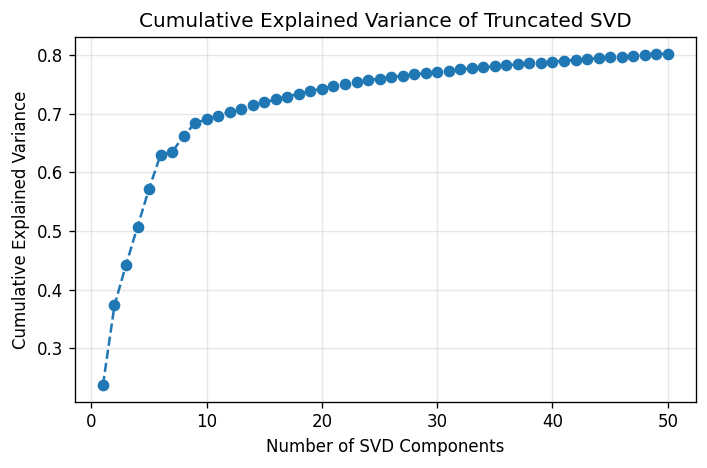

In [4]:
# ===============================
# Step 3: Cumulative Explained Variance (Truncated SVD)
# ===============================

# Choose maximum number of SVD components (up to 50 or one less than number of features)
max_components = min(50, X_processed.shape[1] - 1)
n_components_cum = max_components  # Number of components to compute for variance curve

# Create TruncatedSVD model for many components
svd_cum = TruncatedSVD(n_components=n_components_cum, random_state=42)

# Fit SVD model on processed matrix
svd_cum.fit(X_processed)

# Proportion of variance explained by each component
explained_variance_ratio = svd_cum.explained_variance_ratio_

# Cumulative sum of explained variance ratios
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Cumulative explained variance by SVD components:\n")
# Loop over components and print cumulative variance
for i, var in enumerate(cumulative_variance, start=1):
    print(f"Component {i}: {var:.4f}")

# Plot the cumulative explained variance curve
plt.figure()
plt.plot(
    range(1, n_components_cum + 1),    # X-axis: number of components
    cumulative_variance,               # Y-axis: cumulative explained variance
    marker="o",
    linestyle="--"
)
plt.xlabel("Number of SVD Components")             # Label for x-axis
plt.ylabel("Cumulative Explained Variance")        # Label for y-axis
plt.title("Cumulative Explained Variance of Truncated SVD")  # Plot title
plt.grid(True, alpha=0.3)                          # Light grid
plt.tight_layout()                                 # Adjust layout to avoid clipping
plt.show()                                         # Show the plot


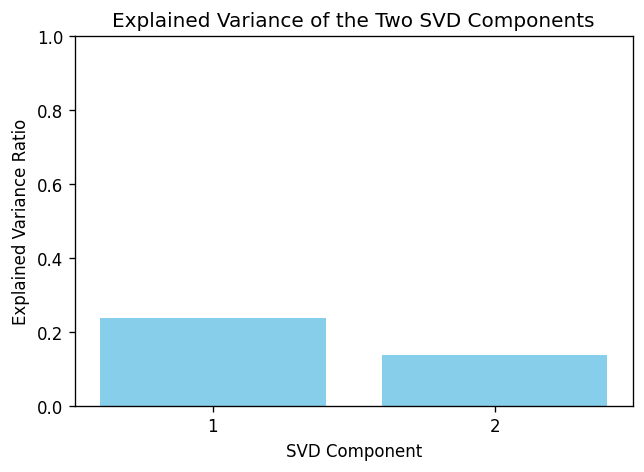

2D reduced shape: (50563, 2)
Explained variance (2D): 0.37311693450578787


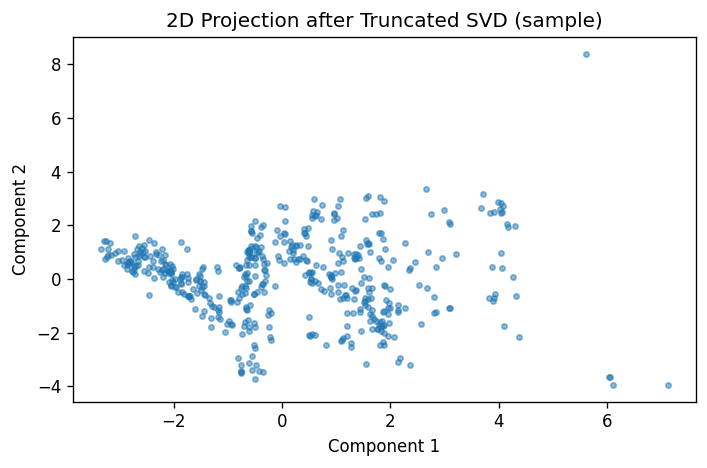

In [11]:
# ===============================
# Step 3b: Reduce to 2D for Visualization & Clustering
# ===============================

# Create a new TruncatedSVD model with 2 components for visualization
svd_2d = TruncatedSVD(n_components=2, random_state=42)

# Transform the processed feature matrix into 2D
X_2d = svd_2d.fit_transform(X_processed)

# ============================================================
# Plot Explained Variance Ratio of the Two SVD Components
# ============================================================

# Create a new figure with a specific size (width=6 inches, height=4 inches)
plt.figure(figsize=(6, 4))

# Define component labels for the x-axis (Component 1 and Component 2)
components = [1, 2]

# Extract how much variance each SVD component explains
# svd_2d.explained_variance_ratio_ returns an array of length 2
explained_var = svd_2d.explained_variance_ratio_

# Create a bar chart: X = component numbers, Y = their explained variance
plt.bar(components, explained_var, color='skyblue')

# Set x-axis tick locations and labels
plt.xticks(components)

# Label the x-axis
plt.xlabel("SVD Component")

# Label the y-axis
plt.ylabel("Explained Variance Ratio")

# Title for the plot
plt.title("Explained Variance of the Two SVD Components")

# Set y-axis limits from 0 to 1 so both bars are visually comparable
plt.ylim(0, 1)

# Save this plot as a PNG file (high resolution, tight bounding box)
plt.savefig("svd_variance.png", dpi=300, bbox_inches='tight')

# Display the plot on screen
plt.show()

print("2D reduced shape:", X_2d.shape)                        # Show shape of reduced data
print("Explained variance (2D):", svd_2d.explained_variance_ratio_.sum())  # Total variance explained by 2 components

# Create a random sample of points for scatter plot (to avoid overplotting)
n = X_2d.shape[0]                       # Total number of samples
sample_size = min(500, n)              # Plot at most 500 points
idx = np.random.choice(n, sample_size, replace=False)  # Random indices without replacement

# Scatter plot of 2D SVD projection
plt.figure()
plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=10, alpha=0.5)  # Each point is a transaction
plt.xlabel("Component 1")                  # X-axis label
plt.ylabel("Component 2")                  # Y-axis label
plt.title("2D Projection after Truncated SVD (sample)")  # Title for the plot
plt.tight_layout()
plt.show()


In [6]:
# ===============================
# Helper Functions for Clustering
# ===============================

def evaluate_clustering(X2d, labels, name):
    """Compute clustering metrics for a given clustering result.

    X2d   : 2D data used for clustering (n_samples, 2)
    labels: cluster labels for each sample
    name  : name of the clustering method (string)
    """
    # Unique labels present in clustering result
    unique_labels = np.unique(labels)
    # Number of clusters, ignoring noise label (-1) if present
    n_clusters = len(unique_labels[unique_labels != -1])

    # Initialize results with NaN metrics
    results = {
        "method": name,
        "n_clusters": n_clusters,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
    }

    # If fewer than 2 clusters, we cannot compute metrics
    if n_clusters < 2:
        return results

    # For methods that mark noise as -1 (e.g. DBSCAN), exclude noise points
    mask = labels != -1
    X_eval = X2d[mask]
    labels_eval = labels[mask]

    # Limit sample size for silhouette score to speed up computation
    sample_size = min(10000, X_eval.shape[0])

    # Silhouette score: higher is better (cohesion vs separation)
    results["silhouette"] = silhouette_score(
        X_eval, labels_eval, sample_size=sample_size, random_state=42
    )

    # Davies–Bouldin index: lower is better
    results["davies_bouldin"] = davies_bouldin_score(X_eval, labels_eval)

    # Calinski–Harabasz index: higher is better
    results["calinski_harabasz"] = calinski_harabasz_score(X_eval, labels_eval)

    return results


def plot_clusters(X2d, labels, title):
    """Visualize clusters on the 2D SVD projection.

    X2d   : 2D data (n_samples, 2)
    labels: cluster labels
    title : title for the plot
    """
    n = X2d.shape[0]                       # Total number of points
    sample_size = min(500, n)             # Plot at most 500 points
    idx = np.random.choice(n, sample_size, replace=False)  # Sample indices
    Xs = X2d[idx]                         # Sampled points
    ls = labels[idx]                      # Corresponding labels

    plt.figure()
    scatter = plt.scatter(
        Xs[:, 0], Xs[:, 1],               # 2D coordinates
        c=ls,                             # Color by cluster label
        s=10,                             # Point size
        alpha=0.6,                        # Transparency
        cmap="tab10"                      # Colormap
    )
    plt.xlabel("Component 1")             # X-axis label
    plt.ylabel("Component 2")             # Y-axis label
    plt.title(title)                      # Plot title
    plt.colorbar(scatter, label="Cluster")  # Colorbar showing cluster IDs
    plt.tight_layout()
    plt.show()


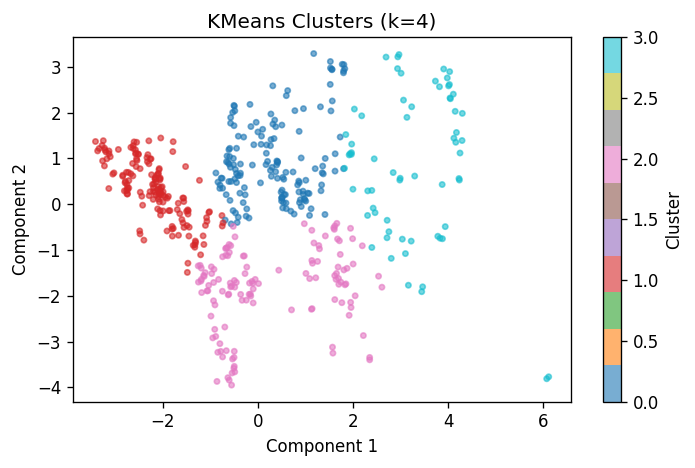

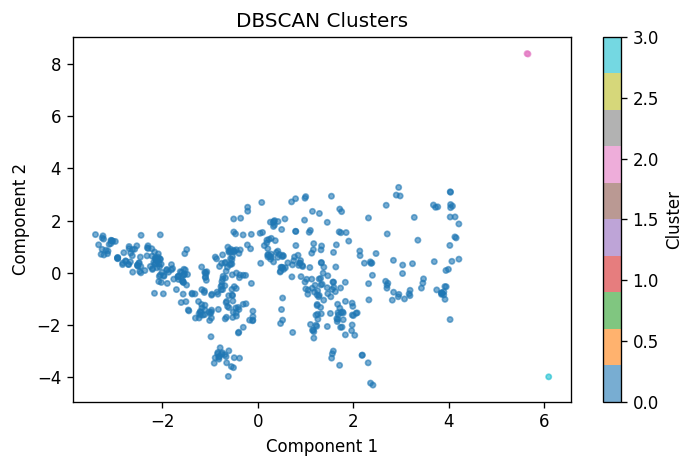

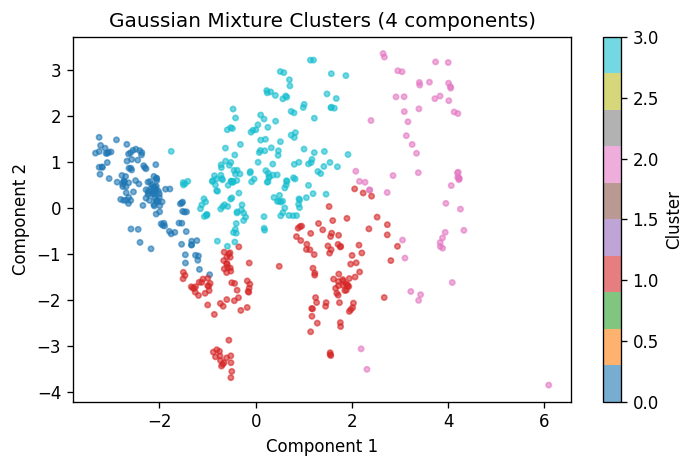


Cluster metrics comparison:
                            method  n_clusters  silhouette  davies_bouldin  \
0                     KMeans (k=4)           4    0.418705        0.848141   
1                           DBSCAN           4    0.570217        0.275299   
2  Gaussian Mixture (4 components)           4    0.386494        0.926226   

   calinski_harabasz  
0       40180.219323  
1         918.798280  
2       33001.144513  

results_df:
                            method  n_clusters  silhouette  davies_bouldin  \
0                     KMeans (k=4)           4    0.418705        0.848141   
1                           DBSCAN           4    0.570217        0.275299   
2  Gaussian Mixture (4 components)           4    0.386494        0.926226   

   calinski_harabasz  
0       40180.219323  
1         918.798280  
2       33001.144513  

===== Cluster Summary (KMeans) =====
         avg_amount    avg_age   top_category
cluster                                      
0         71.09773

In [7]:
# ===============================
# Step 4: Clustering (KMeans, DBSCAN, GMM)
# ===============================

# List to collect clustering metrics for each method
cluster_results = []

# 4.1 KMeans clustering
kmeans = KMeans(
    n_clusters=4,     # Number of clusters we want KMeans to find
    random_state=42,  # Seed for reproducibility
    n_init=10         # Number of random initializations
)
kmeans_labels = kmeans.fit_predict(X_2d)  # Fit KMeans and get cluster labels

# Evaluate KMeans clustering and store metrics
cluster_results.append(
    evaluate_clustering(X_2d, kmeans_labels, "KMeans (k=4)")
)

# Plot KMeans clusters on 2D projection
plot_clusters(X_2d, kmeans_labels, "KMeans Clusters (k=4)")


# 4.2 DBSCAN clustering
dbscan = DBSCAN(
    eps=0.6,         # Neighborhood radius for density
    min_samples=20   # Minimum points to form a dense region
)
dbscan_labels = dbscan.fit_predict(X_2d)  # Fit DBSCAN and get labels (-1 = noise)

# Evaluate DBSCAN clustering and store metrics
cluster_results.append(
    evaluate_clustering(X_2d, dbscan_labels, "DBSCAN")
)

# Plot DBSCAN clusters on 2D projection
plot_clusters(X_2d, dbscan_labels, "DBSCAN Clusters")


# 4.3 Gaussian Mixture Model (GMM) clustering
gmm = GaussianMixture(
    n_components=4,        # Number of Gaussian components (clusters)
    covariance_type="full",# Full covariance matrix for flexibility
    random_state=42        # Seed for reproducibility
)
gmm_labels = gmm.fit_predict(X_2d)  # Fit GMM and get hard cluster labels

# Evaluate GMM clustering and store metrics
cluster_results.append(
    evaluate_clustering(X_2d, gmm_labels, "Gaussian Mixture (4 components)")
)

# Plot GMM clusters on 2D projection
plot_clusters(X_2d, gmm_labels, "Gaussian Mixture Clusters (4 components)")


# 4.4 Convert metrics to DataFrame and print
metrics_df = pd.DataFrame(cluster_results)  # Convert list of dicts to DataFrame
print("\nCluster metrics comparison:")      # Print header
print(metrics_df)                            # Display metrics for each method

# Optional: another view of the same results
results_df = pd.DataFrame(cluster_results)
print("\nresults_df:")
print(results_df)


# 4.5 KMeans-based cluster summary on original (cleaned) data
df_cluster = df_clean.copy()                 # Make a copy of cleaned data
df_cluster["cluster"] = kmeans_labels        # Attach KMeans cluster labels
df_cluster["age"] = df_cluster["age"].astype(float)  # Ensure age is float

# Group by cluster and compute summary statistics
cluster_summary = df_cluster.groupby("cluster").agg(
    avg_amount=("amt", "mean"),                          # Average transaction amount
    avg_age=("age", "mean"),                             # Average age in years
    top_category=("category", lambda x: x.value_counts().idxmax())  # Most frequent category
)

print("\n===== Cluster Summary (KMeans) =====")
print(cluster_summary)                       # Show cluster summary table


# 4.6 KMeans centroids in the 2D SVD space
cluster_centroids = pd.DataFrame(
    kmeans.cluster_centers_,               # Centers of KMeans clusters in 2D
    columns=["Comp1", "Comp2"]             # Name the SVD components
)

print("\nKMeans cluster centroids in SVD space:")
print(cluster_centroids)                    # Display centroid coordinates


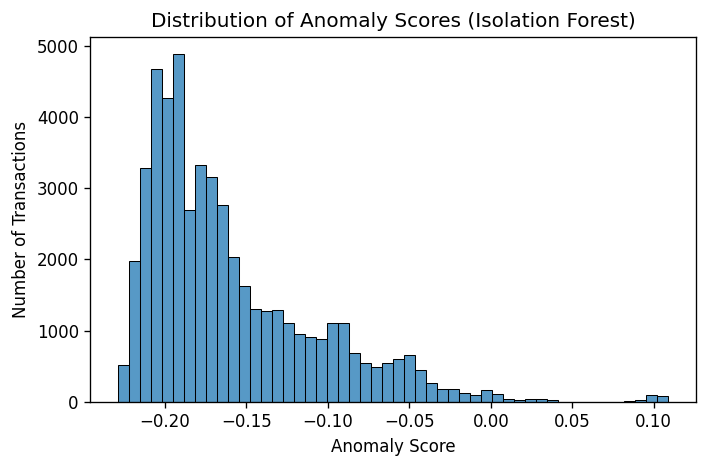

Total points: 50563
Detected anomalies (contamination=1%): 504
Contamination=0.5%, Fraud capture rate=3.25%
Contamination=1.0%, Fraud capture rate=4.77%
Contamination=2.0%, Fraud capture rate=5.42%
Contamination=3.0%, Fraud capture rate=8.68%
Contamination=5.0%, Fraud capture rate=10.85%


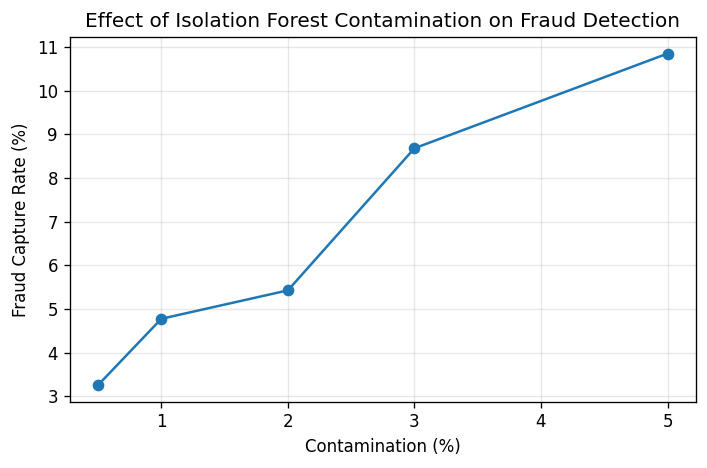

In [9]:
# Step 5: Anomaly Detection (Isolation Forest)


# Initialize Isolation Forest model
iso = IsolationForest(
    n_estimators=100,     # Number of trees in the forest
    contamination=0.01,   # Expected fraction of anomalies (1%)
    random_state=42       # Seed for reproducibility
)

# Fit Isolation Forest on the 2D data and get predictions
iso_labels = iso.fit_predict(X_2d)   # Outputs: 1 for normal, -1 for anomaly

# Create a boolean mask where True indicates an anomaly
anomaly_mask = (iso_labels == -1)

# Compute anomaly scores: higher scores mean more anomalous
anomaly_scores = -iso.decision_function(X_2d)

# Plot histogram of anomaly scores
plt.figure()
sns.histplot(anomaly_scores, bins=50, kde=False)  # Histogram of scores
plt.xlabel("Anomaly Score")                       # X-axis label
plt.ylabel("Number of Transactions")              # Y-axis label
plt.title("Distribution of Anomaly Scores (Isolation Forest)")  # Title
plt.tight_layout()
plt.show()

# Print number of points and anomalies detected
print("Total points:", X_2d.shape[0])
print("Detected anomalies (contamination=1%):", anomaly_mask.sum())

# Prepare to study how contamination affects fraud detection
contamination_values = [0.005, 0.01, 0.02, 0.03, 0.05]  # Different contamination levels
fraud_rates = []                                        # To store fraud capture rate for each level

# Only compute fraud detection metrics if labels are available
if y_label is not None:
    total_frauds = y_label.sum()                        # Total number of fraud cases
    if total_frauds == 0:
        print("No fraud cases in y_label. Cannot compute fraud capture rates.")
    else:
        # Loop over different contamination values
        for c in contamination_values:
            # New Isolation Forest with specific contamination rate
            iso_c = IsolationForest(
                n_estimators=100,
                contamination=c,
                random_state=42
            )
            iso_c.fit(X_2d)                             # Fit model
            anomaly_mask_c = (iso_c.predict(X_2d) == -1)  # Anomalies at this contamination level

            detected_frauds = y_label[anomaly_mask_c].sum()  # Number of true frauds among anomalies
            fraud_rate = detected_frauds / total_frauds      # Fraction of total frauds captured
            fraud_rates.append(fraud_rate)                   # Save fraud rate

            print(f"Contamination={c*100:.1f}%, Fraud capture rate={fraud_rate*100:.2f}%")

        # Plot contamination vs fraud capture rate
        plt.figure()
        plt.plot(
            [c * 100 for c in contamination_values],     # X-axis: contamination in percent
            [f * 100 for f in fraud_rates],              # Y-axis: fraud capture rate in percent
            marker="o"
        )
        plt.xlabel("Contamination (%)")                  # X-axis label
        plt.ylabel("Fraud Capture Rate (%)")             # Y-axis label
        plt.title("Effect of Isolation Forest Contamination on Fraud Detection")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("y_label not available: cannot compute fraud capture rate.")


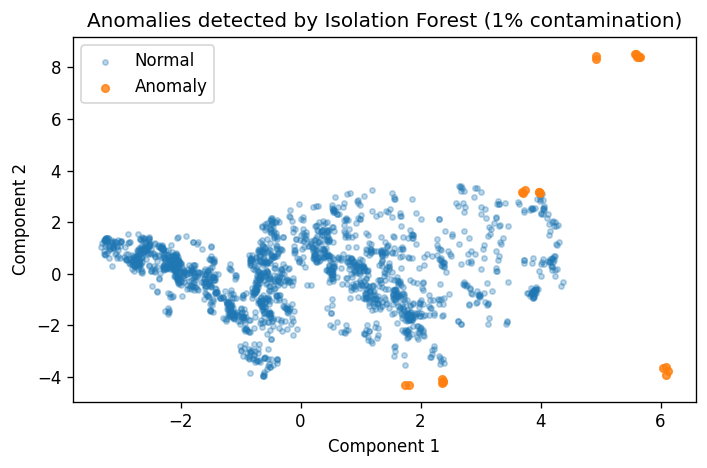


Anomalies per KMeans cluster:
   cluster  total_points  anomalies  anomaly_pct
0        0         15155          0     0.000000
1        1         14935          0     0.000000
2        2         14089        154     1.093051
3        3          6384        350     5.482456

LaTeX table:

\begin{table}
\caption{Anomalies per KMeans Cluster}
\begin{tabular}{rrrr}
\toprule
cluster & total_points & anomalies & anomaly_pct \\
\midrule
0 & 15155 & 0 & 0.00 \\
1 & 14935 & 0 & 0.00 \\
2 & 14089 & 154 & 1.09 \\
3 & 6384 & 350 & 5.48 \\
\bottomrule
\end{tabular}
\end{table}


Sample anomalies (first 10 rows):
                              merchant       category     amt gender  \
28                     fraud_Kunze Inc    grocery_pos   90.22      M   
47                 fraud_Stracke-Lemke    grocery_pos   83.07      F   
235                   fraud_Dach-Nader       misc_net   16.65      F   
236                fraud_Hills-Witting   shopping_net    8.70      M   
256   fraud_Cormier, Stracke an

In [10]:
# ===============================
# Step 6: Anomaly Visualization & Summary
# ===============================

def plot_anomalies(X2d, anomalies_mask, title="Isolation Forest Anomalies"):
    """Plot normal points and anomalies on 2D SVD space.

    X2d           : 2D array of shape (n_samples, 2)
    anomalies_mask: boolean mask, True for anomalies
    title         : plot title
    """
    n = X2d.shape[0]                          # Total number of samples
    sample_size = min(2000, n)               # Use at most 2000 points
    idx = np.random.choice(n, sample_size, replace=False)  # Random subset
    Xs = X2d[idx]                            # Sampled 2D points
    am = anomalies_mask[idx]                 # Corresponding anomaly flags

    plt.figure()
    # Plot normal points
    plt.scatter(
        Xs[~am, 0], Xs[~am, 1],
        s=10, alpha=0.3, label="Normal"
    )
    # Plot anomalous points
    plt.scatter(
        Xs[am, 0], Xs[am, 1],
        s=20, alpha=0.8, label="Anomaly"
    )
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Call the function to visualize anomalies detected at 1% contamination
plot_anomalies(X_2d, anomaly_mask, "Anomalies detected by Isolation Forest (1% contamination)")

# Create a copy of cleaned data and add anomaly flag
anomalies_df = df_clean.copy()
anomalies_df["is_anomaly"] = anomaly_mask

# Keep only rows marked as anomalies
anomaly_rows = anomalies_df[anomalies_df["is_anomaly"]]

# Build a DataFrame linking KMeans cluster labels and anomaly flags
summary_df = pd.DataFrame({
    "cluster": kmeans_labels,   # KMeans cluster label
    "is_anomaly": anomaly_mask  # Whether the point is anomalous
})

# Aggregate counts of total points and anomalies per cluster
anomaly_cluster_summary = summary_df.groupby("cluster").agg(
    total_points=("cluster", "count"),     # Total points in cluster
    anomalies=("is_anomaly", "sum")        # Number of anomalies in cluster
).reset_index()

# Compute percentage of anomalies in each cluster
anomaly_cluster_summary["anomaly_pct"] = (
    anomaly_cluster_summary["anomalies"] / anomaly_cluster_summary["total_points"] * 100
)

print("\nAnomalies per KMeans cluster:")
print(anomaly_cluster_summary)             # Print cluster-level anomaly statistics

# Export the anomaly cluster summary as a LaTeX table (for report)
latex_table = anomaly_cluster_summary.to_latex(
    index=False,
    columns=["cluster", "total_points", "anomalies", "anomaly_pct"],
    caption="Anomalies per KMeans Cluster",
    float_format="%.2f"
)
print("\nLaTeX table:\n")
print(latex_table)

# Show first 10 anomalous transactions for inspection
print("\nSample anomalies (first 10 rows):")
print(anomaly_rows.head(10))

# Compare fraud rate in full dataset vs among detected anomalies
if y_label is not None:
    total_frauds = y_label.sum()          # Total number of fraud cases
    if total_frauds == 0:
        print("\nNo fraud cases in y_label. Fraud rate comparison is not applicable.")
    else:
        # DataFrame linking fraud label and anomaly status
        anomalies_with_label = pd.DataFrame({
            "is_fraud": y_label.values,    # True fraud label (0 or 1)
            "is_anomaly": anomaly_mask     # Anomaly flag (True/False)
        })

        # Fraud rate in entire dataset
        full_fraud_rate = anomalies_with_label["is_fraud"].mean()

        # Fraud rate only among points marked as anomalies
        anomaly_fraud_rate = anomalies_with_label.loc[
            anomalies_with_label["is_anomaly"], "is_fraud"
        ].mean()

        print("\nFraud rate in full data:", full_fraud_rate)
        print("Fraud rate among detected anomalies:", anomaly_fraud_rate)


## Final Notes

This notebook implements the full pipeline required by the project, with detailed comments explaining each step:

- Preprocessing and feature engineering
- Truncated SVD with cumulative explained variance
- Clustering with KMeans, DBSCAN, and GMM
- Comparative clustering metrics
- Isolation Forest anomaly detection with contamination analysis
- Cluster-level and anomaly-level summaries

You can use this notebook as both an analysis tool and a learning resource.
